In [1]:
# Tools
import pandas as pd
from pathlib import Path
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import learning_curve 

# Guardar modelo
import joblib

In [2]:
CSV_INPUT = Path(r"C:\Users\david\Documents\TFG\train_dataset.csv")

data = pd.read_csv(CSV_INPUT)
data

,video_id,stance_label,effect_label,knee_start,knee_min,knee_target,ankle_drag,ankle_min_dist,hip_tilt,jump,lateral_offset,arm_extension,non_dominant_arm_angle,hip_drive,shoulder_rotation,trunk_arch
0,flat_pinpoint_103_landmarks,0,0,168.74,144.97,167.15,23.5143,0.2589,0.9797,6.8047,0.5054,167.2977,178.974424,4.8492,-16.8387,5.5765
1,flat_pinpoint_107_landmarks,0,0,160.42,144.11,157.38,2.0281,1.4618,0.6861,8.0920,0.6803,167.2809,166.908886,2.9115,-16.7237,4.8919
2,flat_pinpoint_113_landmarks,0,0,162.51,106.18,140.36,28.2208,0.0728,0.5855,4.6137,1.3002,167.4573,172.963988,2.8057,-18.7935,1.3067
3,flat_pinpoint_126_landmarks,0,0,179.95,132.05,150.87,8.3358,0.2664,0.4859,19.4299,0.3864,165.5187,179.469276,13.8139,-22.3984,5.3167
4,flat_pinpoint_127_landmarks,0,0,161.47,111.39,160.33,10.3122,0.2143,0.2475,4.7989,0.3795,168.1181,174.810623,2.6229,5.8823,1.4078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,slice_platform_53_landmarks,1,2,178.97,129.01,160.97,19.1265,0.1407,0.1471,8.2059,1.1259,168.9258,177.008537,3.1322,-36.0269,2.1644
242,slice_platform_77_landmarks,1,2,164.73,126.63,138.50,1.7986,2.8344,0.5489,8.4448,1.0551,172.0871,169.453043,3.0144,-30.8618,2.9710
243,slice_platform_82_landmarks,1,2,161.63,128.45,141.59,3.5252,2.1181,0.4736,8.0483,0.6921,162.6849,171.868877,2.4894,72.6841,3.9017
244,slice_platform_85_landmarks,1,2,179.99,137.06,142.16,7.2953,0.6506,0.6777,4.0673,0.7387,161.8273,168.068674,1.8392,-26.0385,0.1497


*We set a configuration specific for each metric*

In [4]:
CONFIGS = {
    "stance": {
        "features": ['knee_start', 'knee_min', 'knee_target', 'ankle_drag', 'ankle_min_dist', 'hip_tilt'],
        "target": "stance_label",
        "mlp_layers": (32, 16),
        "mlp_iter": 2000,
        "mlp_alpha": 0.01,
        "class_weight": None,
    },
    "effect": {
        "features": [
            'jump',
            'lateral_offset', 
            'arm_extension',
            'non_dominant_arm_angle',
            'hip_drive',
            
        ],
        "target": "effect_label",
        "mlp_layers": (64, 32),
        "mlp_iter": 2000,
        "mlp_alpha": 0.001,
        "class_weight": "balanced",
    }
}

*Creamos una función para hallar el modelo ganador*

In [ ]:
#def get_model(df, config_name):
#    cfg = CONFIGS[config_name]
#    print(f"TRAINING: {config_name.upper()}")
#   
#    X = df[cfg["features"]]
#    y = df[cfg["target"]]
#    
#   X_train, X_test, y_train, y_test = train_test_split(
#       X, y, test_size=0.2, stratify=y, random_state=42
#   )
#
#   print(f"Data divided")
#  print(f"    -   We train with {len(X_train)} videos")
# print(f"    -   We test with {len(X_test)} videos")
#   
#   scaler = StandardScaler()
#   X_train_scaled = scaler.fit_transform(X_train)
#   X_test_scaled = scaler.transform(X_test)
    
#  modelos = {
#  "Logistic Regression": LogisticRegression(class_weight=cfg["class_weight"], random_state=42),
# "SVM (Support Vector)": SVC(kernel='rbf', class_weight=cfg["class_weight"], probability=True, random_state=42),
#"Random Forest": RandomForestClassifier(n_estimators=100, class_weight=cfg["class_weight"], random_state=42), # type: ignore
#"Neuronal Network (MLP)": MLPClassifier(
#   hidden_layer_sizes=cfg["mlp_layers"], 
#  max_iter=cfg["mlp_iter"], 
## alpha=cfg["mlp_alpha"], 
#random_state=42
#),
#"KNN (Vecinos)": KNeighborsClassifier(n_neighbors=5)
#}
    
#results = []
    
#print("Initiating Traing and Evaluation:\n")

#    for name, model in modelos.items():
#       model.fit(X_train_scaled, y_train)
#      y_pred = model.predict(X_test_scaled)
#     
#    f1 = f1_score(y_test, y_pred, average='weighted')
#   acc = accuracy_score(y_test, y_pred)

#  results.append({
##     "Model": name,
#   "F1-Score": f1,
#  "Accuracy": acc
# })
        
    
#    df_ranking = pd.DataFrame(results)
#    df_ranking = df_ranking.sort_values(by="F1-Score", ascending=False)
    
#    print(f"RANKING FOR {config_name.upper()}:")
#    print(df_ranking.to_string(index=False)+"\n")


In [ ]:
import joblib # No olvides importar esto arriba del todo

def get_model(df, config_name):
    cfg = CONFIGS[config_name]
    print(f"TRAINING: {config_name.upper()}")
    
    X = df[cfg["features"]]
    y = df[cfg["target"]]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    print(f"Data divided")
    print(f"    -   We train with {len(X_train)} videos")
    print(f"    -   We test with {len(X_test)} videos")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    modelos = {
        "Logistic Regression": LogisticRegression(class_weight=cfg["class_weight"], random_state=42),
        "SVM (Support Vector)": SVC(kernel='rbf', class_weight=cfg["class_weight"], probability=True, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight=cfg["class_weight"], random_state=42),
        "Red Neuronal (MLP)": MLPClassifier(
            hidden_layer_sizes=cfg["mlp_layers"], 
            max_iter=cfg["mlp_iter"], 
            alpha=cfg["mlp_alpha"], 
            random_state=42
        ),
        "KNN (Vecinos)": KNeighborsClassifier(n_neighbors=5)
    }
    
    results = []
    
    # --- VARIABLES PARA GUARDAR EL GANADOR ---
    best_f1 = 0
    best_model = None
    
    print("Training and Evaluation\n")

    for nombre, modelo in modelos.items():
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
        
        f1 = f1_score(y_test, y_pred, average='weighted')
        acc = accuracy_score(y_test, y_pred)
        
        results.append({
            "Modelo": nombre,
            "F1-Score": f1,
            "Accuracy": acc
        })
        
        # --- SI SUPERA EL RÉCORD, LO GUARDAMOS EN LA VARIABLE ---
        if f1 > best_f1:
            best_f1 = f1
            best_model = modelo
            
    
    df_ranking = pd.DataFrame(results)
    df_ranking = df_ranking.sort_values(by="F1-Score", ascending=False)
    
    print(f"RANKING PARA {config_name.upper()}:")
    print(df_ranking.to_string(index=False)+"\n")

    # ==========================================
    # GUARDAR EL MEJOR MODELO Y SU SCALER
    # ==========================================
    model_name = f"model_{config_name}.pkl"
    scaler_name = f"scaler_{config_name}.pkl"
    
    joblib.dump(best_model, model_name)
    joblib.dump(scaler, scaler_name)
    
    # Extraemos el nombre del modelo ganador para imprimirlo
    winner_name = df_ranking.iloc[0]["Modelo"]
    
    print(f"Files saved!")
    print(f" Model ({winner_name}): {model_name}")
    print(f" Scaleer: {scaler_name}\n")
    print("-" * 50)

In [7]:
get_model(data, 'stance')
get_model(data, 'effect')

TRAINING: STANCE
Data divided
    -   We train with 196 videos
    -   We test with 50 videos
Iniciando entrenamiento y evaluación

RANKING PARA STANCE:
              Modelo  F1-Score  Accuracy
 Logistic Regression  0.920667      0.92
       KNN (Vecinos)  0.917718      0.92
       Random Forest  0.900462      0.90
  Red Neuronal (MLP)  0.898022      0.90
SVM (Support Vector)  0.859219      0.86

💾 ¡Archivos guardados con éxito!
   -> Cerebro (Logistic Regression): model_stance.pkl
   -> Escalador: scaler_stance.pkl

--------------------------------------------------
TRAINING: EFFECT
Data divided
    -   We train with 196 videos
    -   We test with 50 videos
Iniciando entrenamiento y evaluación

RANKING PARA EFFECT:
              Modelo  F1-Score  Accuracy
  Red Neuronal (MLP)  0.627837      0.64
       KNN (Vecinos)  0.523496      0.60
       Random Forest  0.505103      0.60
SVM (Support Vector)  0.453713      0.44
 Logistic Regression  0.404844      0.38

💾 ¡Archivos guardados con 

## Visualización comparativa de modelos (Figuras para el TFG)

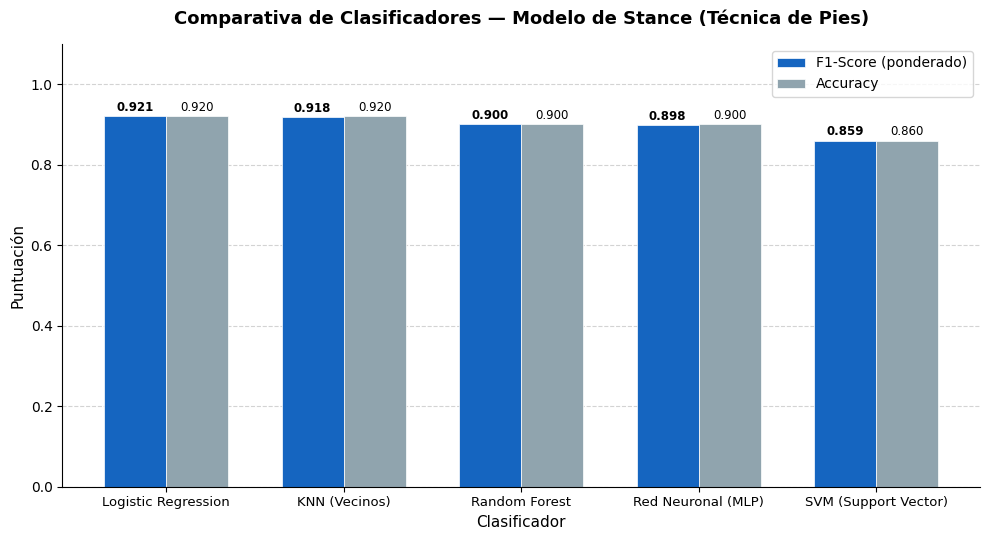

Figura guardada: stance_comparison.png


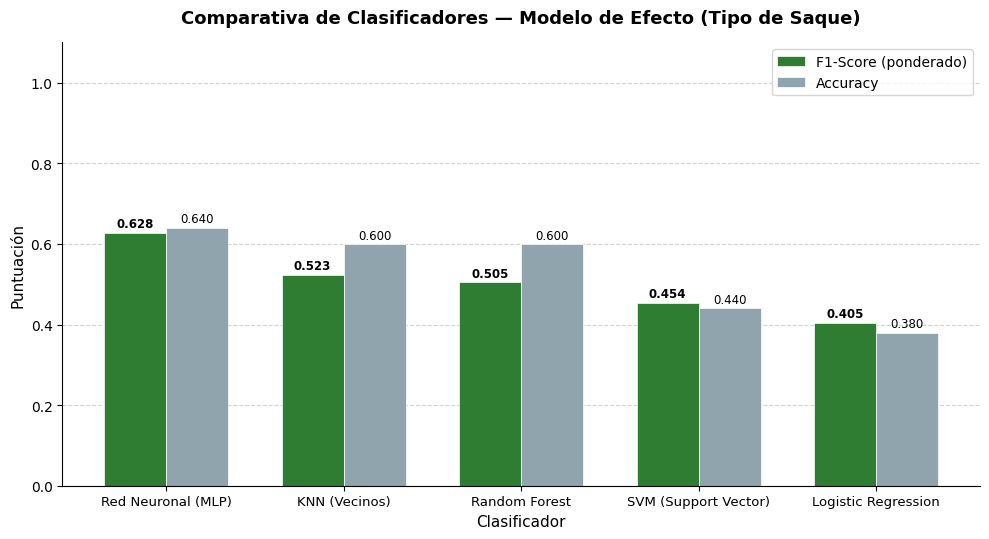

Figura guardada: effect_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ─── Resultados del entrenamiento (random_state=42, deterministas) ───────────
stance_results = {
    'Logistic Regression':  {'F1': 0.920667, 'Accuracy': 0.92},
    'KNN (Vecinos)':         {'F1': 0.917718, 'Accuracy': 0.92},
    'Random Forest':         {'F1': 0.900462, 'Accuracy': 0.90},
    'Red Neuronal (MLP)':    {'F1': 0.898022, 'Accuracy': 0.90},
    'SVM (Support Vector)':  {'F1': 0.859219, 'Accuracy': 0.86},
}

effect_results = {
    'Red Neuronal (MLP)':    {'F1': 0.627837, 'Accuracy': 0.64},
    'KNN (Vecinos)':          {'F1': 0.523496, 'Accuracy': 0.60},
    'Random Forest':          {'F1': 0.505103, 'Accuracy': 0.60},
    'SVM (Support Vector)':   {'F1': 0.453713, 'Accuracy': 0.44},
    'Logistic Regression':    {'F1': 0.404844, 'Accuracy': 0.38},
}

OUTPUT_DIR = Path(r"C:\Users\david\Documents\TFG\model_ai_process_4")

# ─── Función de plot ──────────────────────────────────────────────────────────
def plot_comparison(data, title, filepath, f1_color, acc_color):
    models   = list(data.keys())
    f1_vals  = [data[m]['F1']       for m in models]
    acc_vals = [data[m]['Accuracy'] for m in models]

    x     = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5.5))

    bars_f1  = ax.bar(x - width/2, f1_vals,  width, color=f1_color,  label='F1-Score (ponderado)',
                      edgecolor='white', linewidth=0.5)
    bars_acc = ax.bar(x + width/2, acc_vals, width, color=acc_color, label='Accuracy',
                      edgecolor='white', linewidth=0.5)

    for bar in bars_f1:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    for bar in bars_acc:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.006,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)

    ax.set_xlabel('Clasificador', fontsize=11)
    ax.set_ylabel('Puntuación', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=14)
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9.5)
    ax.set_ylim(0, 1.10)
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.55)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Figura guardada: {filepath.name}")


# ─── Stance ──────────────────────────────────────────────────────────────────
plot_comparison(
    stance_results,
    'Comparativa de Clasificadores — Modelo de Stance (Técnica de Pies)',
    OUTPUT_DIR / 'stance_comparison.png',
    f1_color='#1565C0',
    acc_color='#90A4AE',
)

# ─── Efecto ──────────────────────────────────────────────────────────────────
plot_comparison(
    effect_results,
    'Comparativa de Clasificadores — Modelo de Efecto (Tipo de Saque)',
    OUTPUT_DIR / 'effect_comparison.png',
    f1_color='#2E7D32',
    acc_color='#90A4AE',
)